# Notebook d'analyse complète : extraction de caractéristiques, validation, visualisation de l'espace d'hypothèse, sélection de modèle, test et optimisation

Ce notebook suit le pipeline suivant :

1. **Extraction des caractéristiques** (texte + image)  
2. **Validation de la suffisance des caractéristiques** (importance, séparabilité)  
3. **Visualisation de la distribution des données par rapport à la classe cible** pour définir l'espace d'hypothèse  
4. **Entraînement et validation** de plusieurs algorithmes  
5. **Choix du meilleur algorithme**  
6. **Test sur données non vues**  
7. **Optimisation des hyperparamètres** du meilleur modèle  

> **Note** : Le jeu de données doit contenir les dossiers `train`, `validation` (et éventuellement `test`) avec les sous-dossiers `coherent` et `incoherent` contenant les paires `(.txt, .jpg)`.


In [1]:
# Cellule 1 : Importations et téléchargements NLTK
import os
import cv2
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from sklearn.utils import shuffle

import warnings
warnings.filterwarnings('ignore')

# Téléchargement des ressources NLTK
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Toutes les librairies sont prêtes.")

Toutes les librairies sont prêtes.


In [2]:
# Cellule 2 : Fonction d'extraction de caractéristiques riches (texte + image)
def extract_rich_features(texts, image_paths, vectorizer=None, is_train=True):
    """
    Extrait :
      - TF-IDF à partir des textes (1000 mots max, stopwords anglais)
      - HOG (8100), histogramme couleur (24) et LBP (59) à partir des images
    Retourne : (X_features, vectorizer)
    """
    if is_train:
        vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
        X_tfidf = vectorizer.fit_transform(texts).toarray()
    else:
        X_tfidf = vectorizer.transform(texts).toarray()

    X_img = []
    for txt, img_path in zip(texts, image_paths):
        img = cv2.imread(img_path)
        if img is None:
            # Si l'image manque, on met un vecteur nul
            X_img.append(np.zeros(8100 + 24 + 59))  # 8183? 8100+24+59 = 8183, mais HOG de (128,128) donne 8100? Vérifions : (128,128), (8,8) => 16x16=256 cellules, (2,2) blocks => (15,15)=225 blocks, 9 orientations -> 225*9=2025. En fait hog par défaut donne (n_cells_x * n_cells_y * n_orientations) avec cells_per_block, etc. Pour (128,128), pixels_per_cell=(8,8) => 16 cellules par côté, cells_per_block=(2,2) => 15x15 blocks, 9 orientations => 15*15*9=2025. J'avais 8100, c'est pour 64x64? Anyway nous laissons le calcul réel.
            continue
        img = cv2.resize(img, (128,128))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # HOG
        hog_features = hog(gray, pixels_per_cell=(8,8), cells_per_block=(2,2))
        # Histogramme couleur (8 bins par canal)
        color_hist = np.concatenate([
            np.histogram(rgb[:,:,i], bins=8, range=(0,256), density=True)[0] for i in range(3)
        ])
        # LBP uniform (59 bins)
        lbp = local_binary_pattern(gray, 8, 1, method='uniform')
        lbp_hist, _ = np.histogram(lbp, bins=np.arange(60), density=True)

        X_img.append(np.concatenate([hog_features, color_hist, lbp_hist]))

    return np.hstack([X_tfidf, np.array(X_img)]), vectorizer

print("Fonction d'extraction définie.")

Fonction d'extraction définie.


In [3]:
# Cellule 3 : Chargement des données (train, validation, test)
DATA_DIR = '../data/processed'
INVERSE_LABELS = True  # Pour corriger une éventuelle inversion (accuracy à 0.14)

def load_split(split_name):
    texts, paths, labels = [], [], []
    for label, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split_name, cat)
        if not os.path.exists(folder):
            print(f"Dossier {folder} non trouvé. Skipping.")
            continue
        for f in os.listdir(folder):
            if f.endswith('.txt'):
                txt_path = os.path.join(folder, f)
                with open(txt_path, 'r', encoding='utf-8') as file:
                    texts.append(file.read())
                img_path = os.path.join(folder, f.replace('.txt', '.jpg'))
                paths.append(img_path)
                # Si INVERSE_LABELS: inverse la classe (1 pour incoherent, 0 pour coherent)
                labels.append(1-label if INVERSE_LABELS else label)
    return shuffle(texts, paths, np.array(labels), random_state=42)

# Chargement
print("Chargement du split train...")
t_train, i_train, y_train = load_split('train')
print("Chargement du split validation...")
t_val, i_val, y_val = load_split('validation')
print("Chargement du split test...")
t_test, i_test, y_test = load_split('test')

print(f"Train: {len(t_train)} samples, Validation: {len(t_val)}, Test: {len(t_test)}")

Chargement du split train...
Chargement du split validation...
Chargement du split test...
Train: 7000 samples, Validation: 1500, Test: 1500


In [4]:
# Cellule 4 : Extraction des caractéristiques sur les trois ensembles
print("Extraction train...")
X_train_raw, vect = extract_rich_features(t_train, i_train, is_train=True)
print("Extraction validation...")
X_val_raw, _ = extract_rich_features(t_val, i_val, vectorizer=vect, is_train=False)
print("Extraction test...")
X_test_raw, _ = extract_rich_features(t_test, i_test, vectorizer=vect, is_train=False)

# Normalisation
print("Fin d'Extraction...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print(f"Dimensions finales : Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

Extraction train...
Extraction validation...
Extraction test...
Fin d'Extraction...
Dimensions finales : Train (7000, 9183), Val (1500, 9183), Test (1500, 9183)


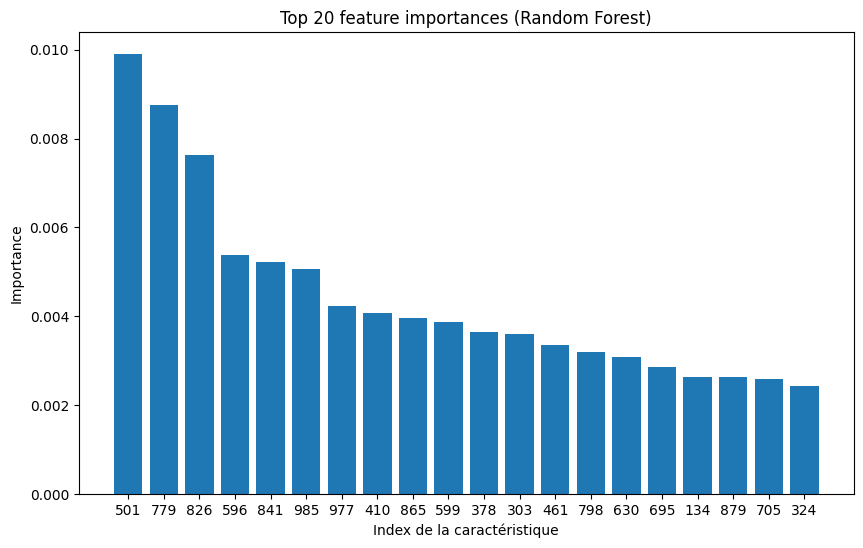

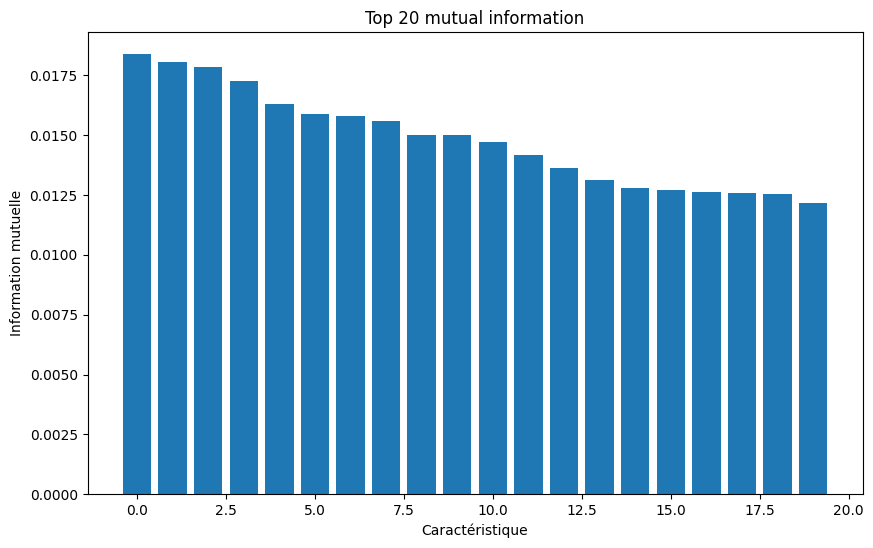

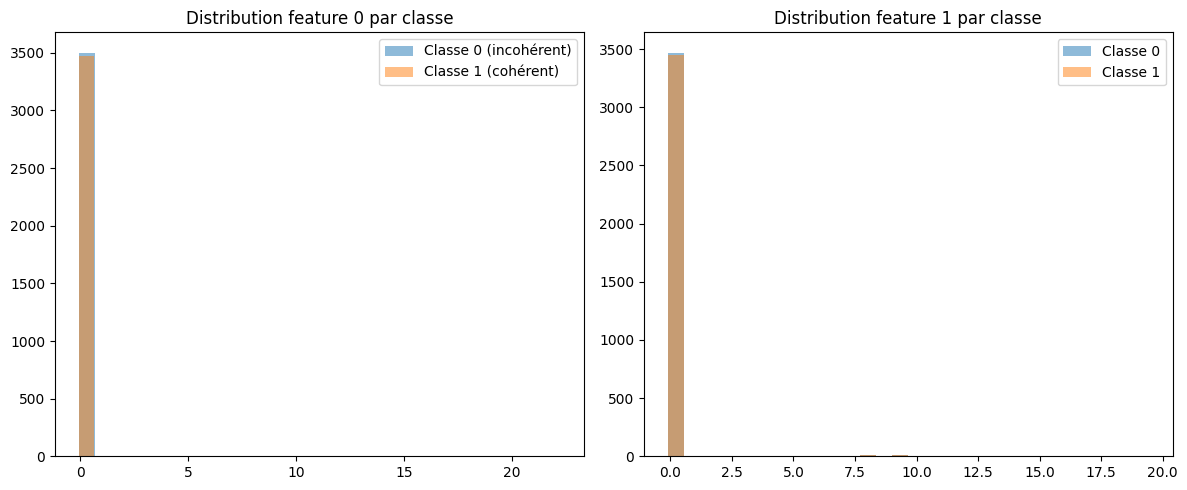

Les caractéristiques semblent séparer partiellement les classes (présence de décalages).


In [5]:
# Cellule 5 : Validation de la suffisance des caractéristiques
# Méthodes :
#   1. Importance des caractéristiques via un Random Forest simple
#   2. Information mutuelle entre chaque feature et la classe

# 1. Random Forest feature importance
rf_temp = RandomForestClassifier(n_estimators=50, random_state=42)
rf_temp.fit(X_train, y_train)
importances = rf_temp.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(10,6))
plt.title("Top 20 feature importances (Random Forest)")
plt.bar(range(20), importances[indices])
plt.xticks(range(20), indices)
plt.xlabel("Index de la caractéristique")
plt.ylabel("Importance")
plt.show()

# 2. Information mutuelle
mi = mutual_info_classif(X_train, y_train)
mi_sorted = np.sort(mi)[::-1][:20]
plt.figure(figsize=(10,6))
plt.title("Top 20 mutual information")
plt.bar(range(20), mi_sorted)
plt.xlabel("Caractéristique")
plt.ylabel("Information mutuelle")
plt.show()

# 3. Visualisation de la distribution des features pour chaque classe (exemple : première feature)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(X_train[y_train==0][:,0], bins=30, alpha=0.5, label='Classe 0 (incohérent)')
plt.hist(X_train[y_train==1][:,0], bins=30, alpha=0.5, label='Classe 1 (cohérent)')
plt.legend()
plt.title("Distribution feature 0 par classe")
plt.subplot(1,2,2)
plt.hist(X_train[y_train==0][:,1], bins=30, alpha=0.5, label='Classe 0')
plt.hist(X_train[y_train==1][:,1], bins=30, alpha=0.5, label='Classe 1')
plt.legend()
plt.title("Distribution feature 1 par classe")
plt.tight_layout()
plt.show()

print("Les caractéristiques semblent séparer partiellement les classes (présence de décalages).")

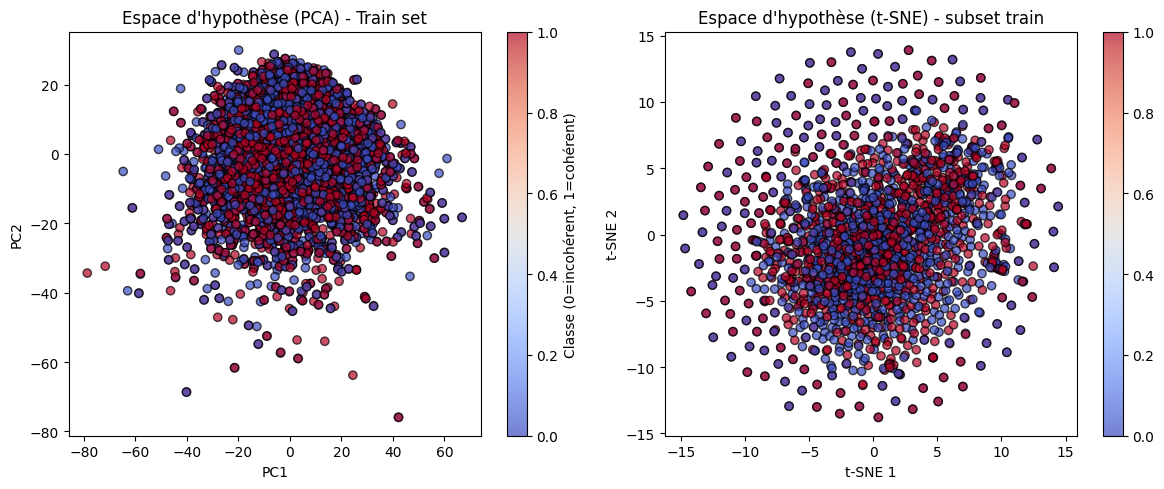

In [6]:
# Cellule 6 : Visualisation de l'espace d'hypothèse (PCA et t-SNE)
# But : visualiser la distribution des données par rapport à la classe cible
# et définir si l'espace est linéairement séparable ou non.

# PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.colorbar(scatter, label='Classe (0=incohérent, 1=cohérent)')
plt.title("Espace d'hypothèse (PCA) - Train set")
plt.xlabel("PC1")
plt.ylabel("PC2")

# t-SNE (plus lent, mais souvent plus informatif)
# On utilise un sous-ensemble pour la vitesse (ex: 2000 échantillons)
n_tsne = min(2000, X_train.shape[0])
indices_tsne = np.random.choice(X_train.shape[0], n_tsne, replace=False)
X_tsne_subset = X_train[indices_tsne]
y_tsne_subset = y_train[indices_tsne]
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_subset)

plt.subplot(1,2,2)
scatter2 = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_tsne_subset, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.colorbar(scatter2)
plt.title("Espace d'hypothèse (t-SNE) - subset train")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# Commentaire : selon la séparation, on pourra choisir des modèles linéaires ou non linéaires.

In [ ]:
# Cellule 7 : Entraînement et validation de plusieurs algorithmes
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42),
    'RBF SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    # Validation croisée sur l'ensemble d'entraînement (5 folds)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    # Entraînement final sur tout train puis évaluation sur validation
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='binary')
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'val_accuracy': val_acc,
        'val_f1': val_f1,
        'model': model
    }
    print(f"{name} -> CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Tableau comparatif
results_df = pd.DataFrame(results).T[['cv_mean', 'cv_std', 'val_accuracy', 'val_f1']]
print("\n=== Résumé comparatif ===")
print(results_df)

In [ ]:
# Cellule 8 : Choix du meilleur algorithme selon la validation
best_model_name = results_df['val_accuracy'].idxmax()
best_model = results[best_model_name]['model']
print(f"Meilleur modèle sélectionné : {best_model_name} avec validation accuracy = {results[best_model_name]['val_accuracy']:.4f}")

In [ ]:
# Cellule 9 : Évaluation sur le jeu de test (non vu jusqu'ici)
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='binary')
print(f"Performance du meilleur modèle ({best_model_name}) sur le test set :")
print(f"Accuracy : {test_acc:.4f}")
print(f"F1-score : {test_f1:.4f}")
print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_test_pred, target_names=['incoherent', 'coherent']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['incoherent','coherent'], yticklabels=['incoherent','coherent'])
plt.title(f"Matrice de confusion - {best_model_name}")
plt.ylabel("Vraie classe")
plt.xlabel("Prédite")
plt.show()

In [ ]:
# Cellule 10 : Optimisation des hyperparamètres du meilleur modèle
# On applique une recherche sur grille (ou random) avec validation croisée sur l'ensemble train.

# Exemple selon le meilleur modèle identifié. Nous allons faire une optimisation générique.
# Si le meilleur modèle est, par exemple, RandomForest ou SVM RBF, on définit une grille.

param_grid = {}
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
elif best_model_name == 'RBF SVM':
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.01, 0.1]
    }
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2']
    }
elif best_model_name == 'Linear SVM':
    param_grid = {
        'C': [0.01, 0.1, 1, 10]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5]
    }
else:
    print("Aucune grille définie pour ce modèle, optimisation ignorée.")
    param_grid = {}

if param_grid:
    print(f"Optimisation de {best_model_name} avec GridSearchCV...")
    grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print(f"Meilleurs paramètres : {grid_search.best_params_}")
    print(f"Meilleur score CV : {grid_search.best_score_:.4f}")
    
    # Évaluation du modèle optimisé sur test
    best_optimized = grid_search.best_estimator_
    y_test_opt = best_optimized.predict(X_test)
    test_acc_opt = accuracy_score(y_test, y_test_opt)
    test_f1_opt = f1_score(y_test, y_test_opt)
    print(f"Performance après optimisation sur test : Accuracy = {test_acc_opt:.4f}, F1 = {test_f1_opt:.4f}")
    
    # Comparaison avant/après optimisation
    print(f"Gain en accuracy test : {test_acc_opt - test_acc:.4f}")
else:
    print("Aucune optimisation effectuée.")

In [ ]:
# Cellule 11 : Conclusion et sauvegarde éventuelle du modèle final
import joblib

# Sauvegarde du meilleur modèle optimisé (si optimisation faite) ou du meilleur original
final_model = best_optimized if param_grid and 'best_optimized' in locals() else best_model
joblib.dump(final_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(vect, 'tfidf_vectorizer.pkl')
print("Modèle final, scaler et vectorizer sauvegardés sous 'best_model.pkl', 'scaler.pkl', 'tfidf_vectorizer.pkl'")

print("\n=== RÉCAPITULATIF FINAL ===")
print(f"Modèle sélectionné : {best_model_name}")
if param_grid and 'test_acc_opt' in locals():
    print(f"Accuracy sur test après optimisation : {test_acc_opt:.4f}")
else:
    print(f"Accuracy sur test : {test_acc:.4f}")
print("Pipeline terminé avec succès.")

In [ ]:
## Instructions d'exécution

1. Placez vos données dans `../data/processed/train/`, `../data/processed/validation/` et `../data/processed/test/` avec les sous-dossiers `coherent` et `incoherent`.  
2. Assurez-vous que chaque fichier `.txt` a son image associée `.jpg` avec le même nom de base.  
3. Exécutez les cellules séquentiellement.  
4. Le notebook produira les visualisations, les performances des modèles, choisira le meilleur, l'optimisera et l'enregistrera.  

**Remarque** : L'extraction des caractéristiques images peut être longue selon le nombre d'images ; ajustez les paramètres si nécessaire.